In [ ]:
suppressMessages(library(ArchR))
suppressMessages(library(ggplot2))
suppressMessages(library(cowplot))
suppressMessages(library(rtracklayer))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(BSgenome.Mmusculus.UCSC.mm39))

In [ ]:
addArchRThreads(threads = 32) 

Setting default number of Parallel threads to 32.



In [ ]:
in_dir = '../../results/04_single_cell_access_atac/09_merge_fragment'
out_dir = '../../results/04_single_cell_access_atac/10_create_archr_project'

# create output directory
if (!dir.exists(out_dir)) {
  dir.create(out_dir, recursive = TRUE)
}

In [ ]:
# create a custom gene annotation from GTF
gtf <- import("../../data/refdata-cellranger-arc-GRCm39-2024-A/genes/genes.gtf.gz")
genes_gr <- gtf[gtf$type == "gene"]
genes_gr$symbol <- genes_gr$gene_name
mcols(genes_gr) <- mcols(genes_gr)[, c("gene_id", "symbol")]

# create exon annotation
exons_gr <- gtf[gtf$type == "exon"]
exons_gr$symbol <- exons_gr$gene_name
mcols(exons_gr) <- mcols(exons_gr)[, c("exon_id", "symbol")]

# get TSS
tss_gr <- import("../../data/refdata-cellranger-arc-GRCm39-2024-A/regions/tss.bed")

geneAnnotation <- createGeneAnnotation(
  TSS = tss_gr, 
  exons = exons_gr, 
  genes = genes_gr
)

genomeAnnotation <- createGenomeAnnotation(genome = BSgenome.Mmusculus.UCSC.mm39)

Getting genome..

Attempting to infer chromSizes..

Attempting to infer blacklist..

Blacklist not downloaded! Continuing without, be careful for downstream biases..



In [ ]:
geneAnnotation

List of length 3
names(3): genes exons TSS

In [ ]:
genomeAnnotation

List of length 3
names(3): genome chromSizes blacklist

In [ ]:
inputFiles <- c("mouse" = glue::glue("{in_dir}/merged.atac.tsv.gz"))
df_barcodes <- read.csv("../../data/10xGenomics/737K-cratac-v1.txt", header = FALSE)

In [ ]:
head(df_barcodes)

,V1
,<chr>
1,GGATAGGGTCATAGCT
2,GGATAGGGTTAGAGAT
3,GGATAGGGTTGCCTGG
4,GGATAGGGTACGCAAG
5,GGATAGGGTAACGGAC
6,GGATAGGGTCAACAGG


In [ ]:
ArrowFiles <- createArrowFiles(
    inputFiles = inputFiles,
    sampleNames = names(inputFiles),
    minTSS = 4, #Dont set this too high because you can always increase later
    minFrags = 1000, 
    maxFrags = 1e7,
    validBarcodes = df_barcodes$V1,
    geneAnnotation = geneAnnotation,
    genomeAnnotation = genomeAnnotation,
    addTileMat = TRUE,
    addGeneScoreMat = TRUE,
    force=TRUE,
    verbose = FALSE
)

Found Gene Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,GL456210.1,GL456211.1,GL456212.1,GL456219.1,GL456221.1,GL456354.1,JH584295.1,JH584296.1,JH584297.1,JH584298.1,JH584299.1,JH584303.1,JH584304.1

Found Exon Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,GL456210.1,GL456211.1,GL456212.1,GL456219.1,GL456221.1,GL456354.1,JH584295.1,JH584296.1,JH584297.1,JH584298.1,JH584299.1,JH584303.1,JH584304.1

Found TSS Seqnames not in GenomeAnnotation chromSizes, Removing : JH584299.1,GL456211.1,GL456221.1,JH584297.1,JH584296.1,GL456354.1,JH584298.1,GL456219.1,GL456210.1,JH584303.1,GL456212.1,JH584304.1,JH584295.1

ArchR logging to : ArchRLogs/ArchR-createArrows-354c3712b1c716-Date-2026-01-11_Time-21-38-11.787714.log
If there is an issue, please report to github with logFile!

Cleaning Temporary Files

subThreading Disabled since ArchRLocking is TRUE see `addArchRLocking`

2026-01-11 21:38:12.258434 : Batch Execution w/ safelapply!, 0 mins elapsed.

(mouse : 1 of 1) 

In [ ]:
proj <- ArchRProject(
  ArrowFiles = ArrowFiles, 
  outputDirectory = out_dir,
  copyArrows = TRUE,
  geneAnnotation = geneAnnotation,
  genomeAnnotation = genomeAnnotation
)

Found Gene Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,GL456210.1,GL456211.1,GL456212.1,GL456219.1,GL456221.1,GL456354.1,JH584295.1,JH584296.1,JH584297.1,JH584298.1,JH584299.1,JH584303.1,JH584304.1

Found Exon Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,GL456210.1,GL456211.1,GL456212.1,GL456219.1,GL456221.1,GL456354.1,JH584295.1,JH584296.1,JH584297.1,JH584298.1,JH584299.1,JH584303.1,JH584304.1

Found TSS Seqnames not in GenomeAnnotation chromSizes, Removing : JH584299.1,GL456211.1,GL456221.1,JH584297.1,JH584296.1,GL456354.1,JH584298.1,GL456219.1,GL456210.1,JH584303.1,GL456212.1,JH584304.1,JH584295.1

Validating Arrows...

Getting SampleNames...

1 


Copying ArrowFiles to Ouptut Directory! If you want to save disk space set copyArrows = FALSE

1 


Getting Cell Metadata...

1 


Merging Cell Metadata...

Initializing ArchRProject...


                                                   / |
                                                 /    \
        

In [ ]:
proj


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /data/pinello/PROJECTS/2025_06_ZL_ACCESS/results/35_scACCESS_mouseAirwayCell/10_create_archr_project 
samples(1): mouse
sampleColData names(1): ArrowFiles
cellColData names(11): Sample TSSEnrichment ... nFrags nDiFrags
numberOfCells(1): 2024
medianTSS(1): 12.572
medianFrags(1): 5788.5

ArchR logging to : ArchRLogs/ArchR-plotTSSEnrichment-354c3729e4135-Date-2026-01-11_Time-21-51-27.746441.log
If there is an issue, please report to github with logFile!

subThreading Disabled since ArchRLocking is TRUE see `addArchRLocking`

2026-01-11 21:51:28.411965 : mouse Computing TSS (1 of 1)!, 0.011 mins elapsed.

2026-01-11 21:51:57.343842 : mouse Finished Computing TSS (1 of 1)!, 0.493 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-plotTSSEnrichment-354c3729e4135-Date-2026-01-11_Time-21-51-27.746441.log



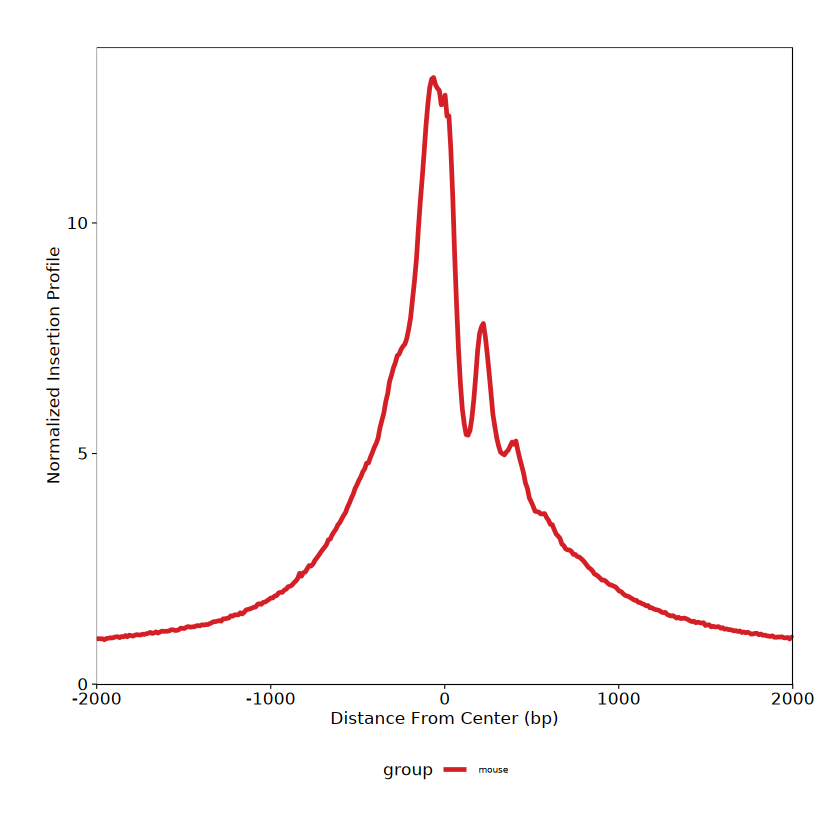

In [ ]:
 plotTSSEnrichment(ArchRProj = proj)

In [ ]:
mean(proj@cellColData$nFrags)

[1] 11228.17

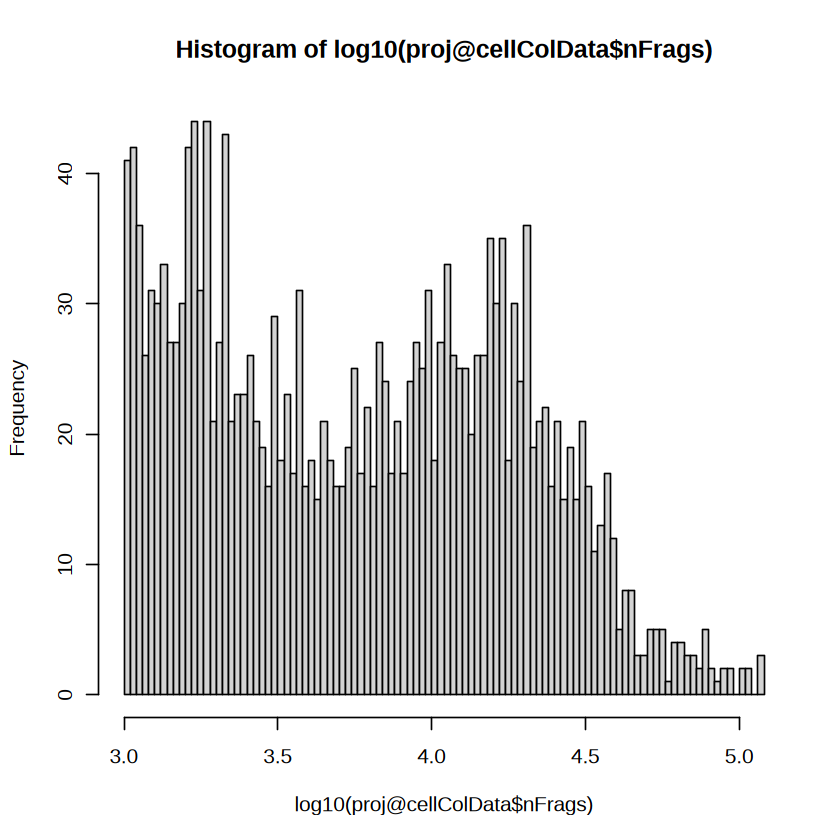

In [ ]:
hist(log10(proj@cellColData$nFrags), breaks=100)

In [ ]:
# options(repr.plot.height = 6, repr.plot.width = 6)

# df <- as.data.frame(proj@cellColData)

# for(sample in unique(df$Sample)){
#     df.plot <- subset(df, Sample == sample)
    
#     df2 <- subset(df.plot, TSSEnrichment >= 4 & nFrags >= 1000)
#     n_cells <- nrow(df2)
    
#     p <- ggPoint(x = log10(df.plot$nFrags), y = df.plot$TSSEnrichment, 
#                  colorDensity = TRUE, continuousSet = "blueYellow", 
#                  xlim = c(1, 5),
#                  title = glue::glue("{sample}, # of cells: {n_cells}")) +
#             geom_hline(yintercept = 4) + 
#             geom_vline(xintercept = 3) +
#             theme_cowplot() +
#             theme(legend.position = 'none') +
#             xlab("Unique fragments") + 
#             ylab("Tss enrichment")
    
#     print(p)
    
#     #write.csv(df2, glue::glue('{output_dir}/{sample}.csv'))
# }

In [ ]:
proj <- addDoubletScores(proj)

ArchR logging to : ArchRLogs/ArchR-addDoubletScores-354c37505ac74a-Date-2026-01-11_Time-21-51-58.007025.log
If there is an issue, please report to github with logFile!

2026-01-11 21:51:58.203658 : Batch Execution w/ safelapply!, 0 mins elapsed.

2026-01-11 21:51:58.214799 : mouse (1 of 1) :  Computing Doublet Statistics, 0 mins elapsed.

Filtering 1 dims correlated > 0.75 to log10(depth + 1)

Biased Clusters : 
Cluster5 


mouse (1 of 1) : UMAP Projection R^2 = 0.94202

mouse (1 of 1) : UMAP Projection R^2 = 0.94202

ArchR logging successful to : ArchRLogs/ArchR-addDoubletScores-354c37505ac74a-Date-2026-01-11_Time-21-51-58.007025.log



In [ ]:
proj <- addIterativeLSI(
    ArchRProj = proj,
    useMatrix = "TileMatrix", 
    name = "IterativeLSI", 
    iterations = 1, 
    clusterParams = list( #See Seurat::FindClusters
        resolution = c(0.2), 
        sampleCells = 10000, 
        n.start = 10
    ), 
    varFeatures = 250000, 
    dimsToUse = 1:30
)

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-354c3731806b4a-Date-2026-01-11_Time-21-53-06.248949.log
If there is an issue, please report to github with logFile!

2026-01-11 21:53:06.583645 : Computing Total Across All Features, 0.001 mins elapsed.

2026-01-11 21:53:07.603974 : Computing Top Features, 0.018 mins elapsed.

###########
2026-01-11 21:53:09.686845 : Running LSI (1 of 1) on Top Features, 0.052 mins elapsed.
###########

2026-01-11 21:53:09.701099 : Creating Partial Matrix, 0.053 mins elapsed.

2026-01-11 21:53:20.57504 : Computing LSI, 0.234 mins elapsed.

2026-01-11 21:53:57.813188 : Finished Running IterativeLSI, 0.854 mins elapsed.



In [ ]:
proj <- addUMAP(
    ArchRProj = proj, 
    reducedDims = "IterativeLSI", 
    name = "UMAP", 
    nNeighbors = 30, 
    minDist = 0.5, 
    metric = "cosine"
)

21:53:57 UMAP embedding parameters a = 0.583 b = 1.334

21:53:57 Non-integer 'n_threads' provided. Setting to 128

21:53:57 Read 2024 rows and found 30 numeric columns

21:53:57 Using Annoy for neighbor search, n_neighbors = 30

21:53:57 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

21:53:58 Writing NN index file to temp file /data/pinello/tmp/zl_tmp/Rtmp0z6aQj/file354c37214f2477

21:53:58 Searching Annoy index using 128 threads, search_k = 3000

21:53:58 Annoy recall = 100%

21:53:59 Commencing smooth kNN distance calibration using 128 threads
 with target n_neighbors = 30

21:54:01 Initializing from normalized Laplacian + noise (using RSpectra)

21:54:01 Commencing optimization for 500 epochs, with 97120 positive edges

21:54:01 Using rng type: pcg

21:54:04 Optimi

In [ ]:
p1 <- plotEmbedding(ArchRProj = proj, colorBy = "cellColData", 
name = "Sample", embedding = "UMAP")
p2 <- plotEmbedding(ArchRProj = proj, colorBy = "cellColData", 
name = "DoubletScore", embedding = "UMAP")

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-354c376d7d4084-Date-2026-01-11_Time-21-54-05.596636.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-354c376d7d4084-Date-2026-01-11_Time-21-54-05.596636.log

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-354c377dd2d921-Date-2026-01-11_Time-21-54-06.119335.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-354c377dd2d921-Date-2026-01-11_Time-21-54-06.119335.log



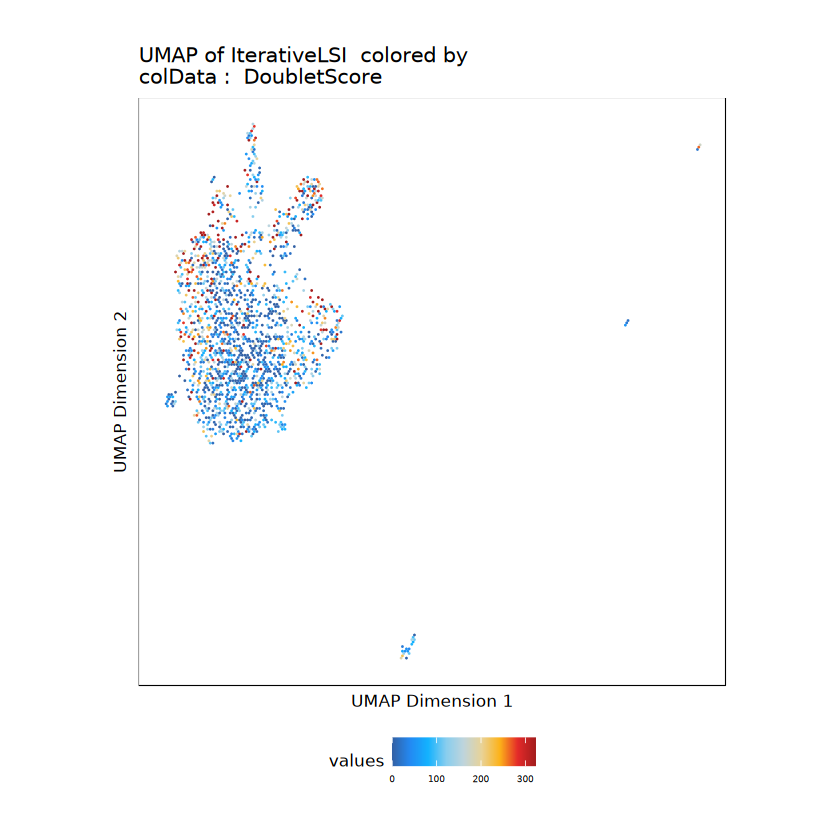

In [ ]:
print(p2)

In [ ]:
nrow(proj@cellColData)

[1] 2024

In [ ]:
proj <- addGroupCoverages(ArchRProj = proj,
                          groupBy = "Sample",
                          minCells = nrow(proj@cellColData),
                          maxCells = 2 * nrow(proj@cellColData),
                          maxReplicates = 1,
                          maxFragments = 1e10,
                          sampleRatio = 1.0,
                          force = TRUE)

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-354c377e362c6e-Date-2026-01-11_Time-21-54-07.470588.log
If there is an issue, please report to github with logFile!

Skipping validation of empty chromosomes since `force` = TRUE!

mouse (1 of 1) : CellGroups N = 1

2026-01-11 21:54:07.898937 : Creating Coverage Files!, 0.007 mins elapsed.

2026-01-11 21:54:07.901867 : Batch Execution w/ safelapply!, 0.007 mins elapsed.

2026-01-11 21:54:07.906687 : Group mouse._.Rep1 (1 of 1) : Creating Group Coverage File : mouse._.Rep1.insertions.coverage.h5, 0.007 mins elapsed.

Number of Cells = 2024

Coverage File Exists!

Added Coverage Group

Added Metadata Group

Added ArrowCoverage Class

Added Coverage/Info

Added Coverage/Info/CellNames

2026-01-11 21:54:55.852194 : Adding Kmer Bias to Coverage Files!, 0.806 mins elapsed.

Completed Kmer Bias Calculation

Adding Kmer Bias (1 of 1)

2026-01-11 21:55:03.092426 : Finished Creation of Coverage Files!, 0.927 mins elapsed.

ArchR logging succes

In [ ]:
## peak calling
proj <- addReproduciblePeakSet(
    ArchRProj = proj, 
    groupBy = "Sample", 
    cutOff = 0.01,
    pathToMacs2 = "/data/pinello/SHARED_SOFTWARE/envs/zl002_envs/zl_macs2/bin/macs2",
    plot = FALSE,
    genomeSize = "mm",
  geneAnnotation = geneAnnotation,
  genomeAnnotation = genomeAnnotation
)

Found Gene Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,GL456210.1,GL456211.1,GL456212.1,GL456219.1,GL456221.1,GL456354.1,JH584295.1,JH584296.1,JH584297.1,JH584298.1,JH584299.1,JH584303.1,JH584304.1

Found Exon Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,GL456210.1,GL456211.1,GL456212.1,GL456219.1,GL456221.1,GL456354.1,JH584295.1,JH584296.1,JH584297.1,JH584298.1,JH584299.1,JH584303.1,JH584304.1

Found TSS Seqnames not in GenomeAnnotation chromSizes, Removing : JH584299.1,GL456211.1,GL456221.1,JH584297.1,JH584296.1,GL456354.1,JH584298.1,GL456219.1,GL456210.1,JH584303.1,GL456212.1,JH584304.1,JH584295.1

ArchR logging to : ArchRLogs/ArchR-addReproduciblePeakSet-354c3733a1b088-Date-2026-01-11_Time-21-55-05.614962.log
If there is an issue, please report to github with logFile!

Calling Peaks with Macs2

2026-01-11 21:55:06.009951 : Peak Calling Parameters!, 0.007 mins elapsed.



      Group nCells nCellsUsed nReplicates nMin nMax maxPeaks
mouse mouse   2024       2024           1 2024 2024   150000


2026-01-11 21:55:06.026328 : Batching Peak Calls!, 0.007 mins elapsed.

2026-01-11 21:55:06.075055 : Batch Execution w/ safelapply!, 0 mins elapsed.

2026-01-11 21:55:06.078583 : Group 1 of 1, Calling Peaks with MACS2!, 0 mins elapsed.

Running Macs2 with Params : macs2 callpeak -g mm --name mouse._.Rep1-1 --treatment /data/pinello/PROJECTS/2025_06_ZL_ACCESS/results/35_scACCESS_mouseAirwayCell/10_create_archr_project/PeakCalls/Sample/InsertionBeds/mouse._.Rep1-1.insertions.bed --outdir /data/pinello/PROJECTS/2025_06_ZL_ACCESS/results/35_scACCESS_mouseAirwayCell/10_create_archr_project/PeakCalls/Sample/InsertionBeds --format BED --call-summits --keep-dup all --nomodel --nolambda --shift -75 --extsize 150 -q 0.01

2026-01-11 21:57:55.55811 : Identifying Reproducible Peaks!, 2.832 mins elapsed.

Annotating Peaks : Nearest Gene

Annotating Peaks : Gene

Annotating Peaks : TSS

Annotating Peaks : GC



[1] "/data/pinello/PROJECTS/2025_06_ZL_ACCESS/results/35_scACCESS_mouseAirwayCell/10_create_archr_project/PeakCalls/Sample/mouse-reproduciblePeaks.gr.rds"


2026-01-11 21:58:01.764729 : Creating Union Peak Set!, 2.936 mins elapsed.

Converged after 1 iterations!

2026-01-11 21:58:05.302056 : Finished Creating Union Peak Set (139613)!, 2.995 mins elapsed.



In [ ]:
proj <- addPeakMatrix(proj, binarize=TRUE)

ArchR logging to : ArchRLogs/ArchR-addPeakMatrix-354c377d3dce62-Date-2026-01-11_Time-21-58-05.512312.log
If there is an issue, please report to github with logFile!

2026-01-11 21:58:05.66881 : Batch Execution w/ safelapply!, 0 mins elapsed.

2026-01-11 21:58:06.249962 : Adding mouse to PeakMatrix for Chr (1 of 20)!, 0.009 mins elapsed.

2026-01-11 21:58:10.124004 : Adding mouse to PeakMatrix for Chr (2 of 20)!, 0.073 mins elapsed.

2026-01-11 21:58:13.659574 : Adding mouse to PeakMatrix for Chr (3 of 20)!, 0.132 mins elapsed.

2026-01-11 21:58:16.995947 : Adding mouse to PeakMatrix for Chr (4 of 20)!, 0.188 mins elapsed.

2026-01-11 21:58:20.192004 : Adding mouse to PeakMatrix for Chr (5 of 20)!, 0.241 mins elapsed.

2026-01-11 21:58:23.398938 : Adding mouse to PeakMatrix for Chr (6 of 20)!, 0.295 mins elapsed.

2026-01-11 21:58:26.613356 : Adding mouse to PeakMatrix for Chr (7 of 20)!, 0.348 mins elapsed.

2026-01-11 21:58:29.957484 : Adding mouse to PeakMatrix for Chr (8 of 20)!, 0.

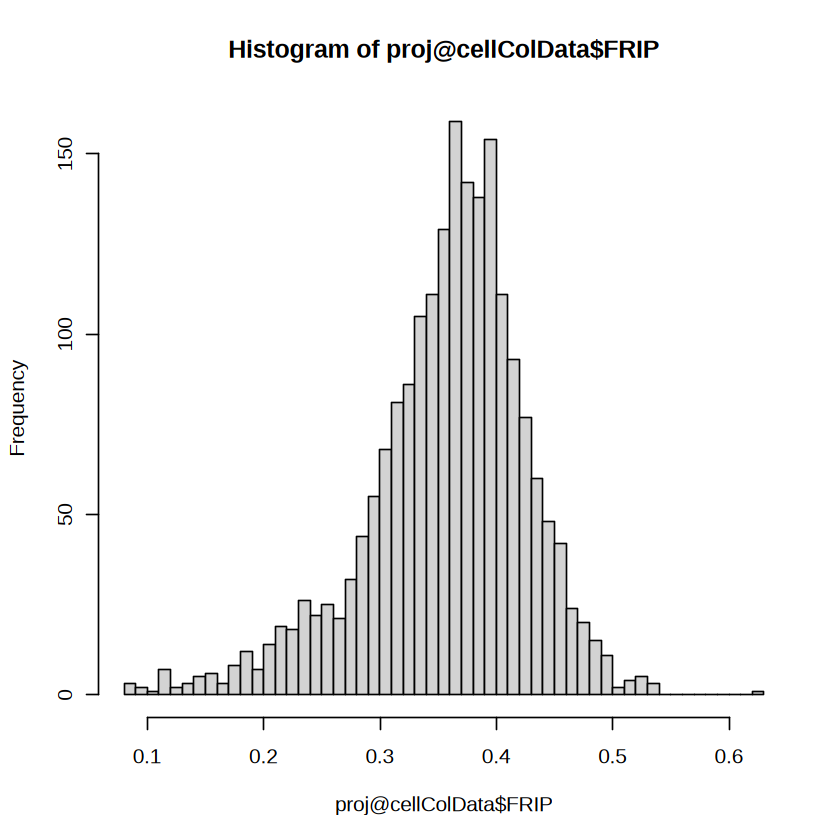

In [ ]:
hist(proj@cellColData$FRIP, breaks=50)

In [ ]:
## save peak matrix
peakMatrix <- getMatrixFromProject(proj,
                                   useMatrix = "PeakMatrix",
                                   binarize = TRUE)

counts <- peakMatrix@assays@data$PeakMatrix
df_ranger <- as.data.frame(peakMatrix@rowRanges@ranges)

rownames(counts) <- paste(peakMatrix@rowRanges@seqnames,
                          df_ranger$start, df_ranger$end, sep = "_") 

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-354c3739f8cca-Date-2026-01-11_Time-21-59-10.097842.log
If there is an issue, please report to github with logFile!

2026-01-11 21:59:13.924342 : Organizing colData, 0.064 mins elapsed.

2026-01-11 21:59:13.929239 : Organizing rowData, 0.064 mins elapsed.

2026-01-11 21:59:13.933995 : Organizing rowRanges, 0.064 mins elapsed.

2026-01-11 21:59:13.942845 : Organizing Assays (1 of 1), 0.064 mins elapsed.

2026-01-11 21:59:13.949544 : Constructing SummarizedExperiment, 0.064 mins elapsed.

2026-01-11 21:59:15.858704 : Finished Matrix Creation, 0.096 mins elapsed.



In [ ]:
dim(counts)

[1] 139613   2024

In [ ]:
saveRDS(counts, file = glue::glue("{out_dir}/PeakMatrix.Rds"))

In [ ]:
## Save data
saveArchRProject(ArchRProj = proj, 
                 load = FALSE)

Saving ArchRProject...



In [ ]:
## Session information
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 20.04.6 LTS

Matrix products: default
BLAS/LAPACK: /data/pinello/SHARED_SOFTWARE/envs/zl002_envs/zl_access/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

Random number generation:
 RNG:     L'Ecuyer-CMRG 
 Normal:  Inversion 
 Sample:  Rejection 
 
locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
 [1] parallel  stats4    grid      stats     graphics  grDevices utils    
 [8] datasets  methods   base     

other attached packages:
 [1] hexbin_1.28.5                      nabor_0.5.0                       
 [3] future_1